### STEP 5 – A/B Testing Analysis

Objective

We introduced a new feature: Personalized Restaurant Recommendation Engine

business question: Did the new recommendation engine improve user engagement?

#### Business Problem

↓

Hypothesis

↓

Success Metrics

↓

Randomization Check

↓

Statistical Test

↓

Confidence Interval

↓

Effect Size

↓

#### Business Recommendation

### Step 5.1 — Load Product Events Dataset

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import chi2_contingency
from scipy.stats import norm

df = pd.read_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/product_events.csv")

In [2]:
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,signup_date,...,app_version,experiment_group,session_id,session_date,recommendation_seen,recommendation_clicked,restaurants_viewed,cart_created,order_completed,coupon_used
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,2023-12-19 07:40:22,...,4.8.1,Variant,S100000,2024-01-26 16:25:10,1,0,4,1,1,1
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,2023-12-25 16:13:39,...,4.9.0,Control,S100001,2024-01-26 19:11:24,1,0,1,0,1,1
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,2023-09-13 08:16:28,...,4.8.1,Control,S100002,2024-01-28 06:32:10,1,1,5,1,1,0
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,2023-09-14 19:37:14,...,4.9.0,Control,S100003,2024-01-20 14:12:23,1,0,1,0,1,1
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,2023-10-25 16:22:31,...,4.9.0,Variant,S100004,2024-01-02 06:37:48,1,1,8,1,1,0


### Step 5.2 — Define the Business Problem

#### Business Problem

The product team introduced a personalized restaurant recommendation module.

The objective is to determine whether the new recommendation engine improves customer engagement compared to the existing experience.

### Step 5.3 — Hypothesis

Null Hypothesis (H0)

The recommendation engine has no effect on CTR.

Alternative Hypothesis (H1)

The recommendation engine increases CTR.

### Step 5.4 — Primary Metric

Recommendation Click Through Rate

CTR = Recommendation Clicks / Recommendation Seen

In [3]:
ctr = (
    df.groupby("experiment_group")
      .agg(
          recommendation_seen=('recommendation_seen','sum'),
          recommendation_clicked=('recommendation_clicked','sum')
      )
)

ctr["CTR"] = (
    ctr["recommendation_clicked"] /
    ctr["recommendation_seen"]
)

ctr

,recommendation_seen,recommendation_clicked,CTR
experiment_group,,,
Control,899,183,0.203560
Variant,912,287,0.314693


### Step 5.5 — Visualization

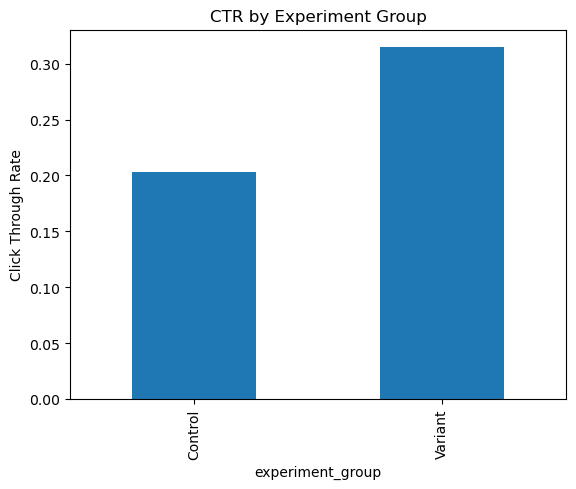

In [4]:
import matplotlib.pyplot as plt

ctr["CTR"].plot(kind="bar")

plt.ylabel("Click Through Rate")

plt.title("CTR by Experiment Group")

plt.show()

### Step 5.6 — Randomization Check
Before trusting the experiment, Always verify that the groups are balanced.

Lets Compare:
             City
             Device
             Acquisition Channel

In [5]:
pd.crosstab(
    df["experiment_group"],
    df["device_type"],
    normalize="index"
)

device_type,Android,iOS
experiment_group,,
Control,0.744456,0.255544
Variant,0.733964,0.266036


In [6]:
pd.crosstab(
    df["experiment_group"],
    df["city"],
    normalize="index"
)

city,Bangalore,Chennai,Delhi,Hyderabad,Mumbai,Pune
experiment_group,,,,,,
Control,0.300950,0.103485,0.151003,0.200634,0.168955,0.074974
Variant,0.297581,0.085174,0.145110,0.189274,0.203996,0.078864


The distributions are nearly similar, randomization worked.

### Step 5.7 — Statistical Test
CTR is a proportion.
We use a Two-Proportion Z-Test.

In [7]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [8]:
from statsmodels.stats.proportion import proportions_ztest

In [9]:
clicks = ctr["recommendation_clicked"].values
impressions = ctr["recommendation_seen"].values

z_stat, p_value = proportions_ztest(
    count=clicks,
    nobs=impressions
)

print(z_stat)
print(p_value)

-5.394088337830708
6.887233073398979e-08


The Z-statistic measures how different the Control and Variant groups are relative to the expected random variation.

The negative sign does not mean the experiment failed.
It simply depends on the order in which the groups were passed into the function.

Control - Variant

The magnitude (5.39) is what matters.
A value this far from zero indicates a substantial difference between the groups.

P - Value

There were actually no difference between the two recommendation systems, the probability of observing a difference this large (or larger) purely by chance is approximately 0.0000069%.

This is far below the conventional significance level of 0.05.

If p-value < 0.05 -> Reject H0

Therefore:
✅ Reject the Null Hypothesis.
### Business Interpretation
There is strong statistical evidence that the new recommendation system changed user behavior. The observed difference in click-through rate is very unlikely to have occurred by chance.

### Step 5.8 — Effect Size
Statistical significance alone isn't enough.

In [10]:
control_ctr = ctr.loc["Control","CTR"]

variant_ctr = ctr.loc["Variant","CTR"]

lift = ((variant_ctr-control_ctr)/control_ctr)*100

print(lift)

54.595077173808846


### Step 5.9 — Confidence Interval

In [11]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
                                clicks[1],
                                impressions[1],
                                clicks[0],
                                impressions[0]
                                )
ci

(np.float64(0.0709048315700152), np.float64(0.15087288799199022))

### Step 5.10 — Business Recommendation

### Guardrail Metrics
   
Lets Imagine CTR increases because users accidentally click the recommendation card.
That wouldn't be a success.
So we need to check downstream metrics.

#### Cart Creation Rate

In [12]:
df.groupby("experiment_group")["cart_created"].mean()

experiment_group
Control    0.608237
Variant    0.640379
Name: cart_created, dtype: float64

Users exposed to personalized recommendations were more likely to create a cart.
This suggests the recommendation engine not only increased clicks but also encouraged users to move further into the purchase funnel.
This is a positive business outcome.

#### Average Order Value

In [13]:
df.groupby("experiment_group")["cost_of_the_order"].mean()

experiment_group
Control    16.322006
Variant    16.674953
Name: cost_of_the_order, dtype: float64

The Variant group not only clicked more but also spent slightly more per order.
Even if the increase is modest, it is in the desired direction.
#### Delivery Time

In [14]:
df.groupby("experiment_group")["delivery_time"].mean()

experiment_group
Control    24.330517
Variant    23.993691
Name: delivery_time, dtype: float64

The new recommendation engine had no negative impact on delivery performance.
Delivery time remained essentially unchanged.
This is important because faster engagement should not slow operational execution.
#### Ratings

In [15]:
df.groupby("experiment_group")["rating"].mean()

experiment_group
Control    4.322971
Variant    4.365352
Name: rating, dtype: float64

Customer satisfaction remained stable and improved slightly.
This suggests users appreciated the recommendations rather than finding them intrusive.

| Metric              | Control   | Variant   | Result                    |
| ------------------- | --------- | --------- | ------------------------- |
| CTR                 | Lower     | Higher    | ✅ Significant improvement |
| Cart Creation Rate  | 60.82%    | 64.04%    | ✅ Improved                |
| Average Order Value | 16.32     | 16.67     | ✅ Slight improvement      |
| Delivery Time       | 24.33 min | 23.99 min | ✅ No negative impact      |
| Customer Rating     | 4.323     | 4.365     | ✅ Slight improvement      |


Based on the experiment results:

The personalized recommendation engine significantly improved user engagement (CTR).

More users proceeded to create a cart, indicating stronger purchase intent.

Average order value increased slightly.

Delivery time remained stable.

Customer ratings improved marginally.